In [1]:
import sys

print(sys.executable)

C:\Users\USER\anaconda3\envs\email_spam\python.exe


In [105]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn

In [26]:
plt.style.use("ggplot")

In [27]:
df = pd.read_csv("email.csv")
df

,Category,Message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."
...,...,...
5568,ham,Will ü b going to esplanade fr home?
5569,ham,"Pity, * was in mood for that. So...any other s..."
5570,ham,The guy did some bitching but I acted like i'd...
5571,ham,Rofl. Its true to its name


In [28]:
df.tail(1)

,Category,Message
5572,"{""mode"":""full""",isActive:false}


In [29]:
df["Category"].value_counts()

Category
ham               4825
spam               747
{"mode":"full"       1
Name: count, dtype: int64

In [30]:
#df.iloc[0:3]

In [31]:
# Remove the last row of the data set 
df = df.iloc[:-1]

In [32]:
df.tail()

,Category,Message
5567,spam,This is the 2nd time we have tried 2 contact u...
5568,ham,Will ü b going to esplanade fr home?
5569,ham,"Pity, * was in mood for that. So...any other s..."
5570,ham,The guy did some bitching but I acted like i'd...
5571,ham,Rofl. Its true to its name


In [34]:
df.shape

(5572, 2)

In [48]:
df.loc[[5567]]

,Category,Message
5567,spam,This is the 2nd time we have tried 2 contact u...


In [42]:
df.iloc[0:2]

,Category,Message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...


In [49]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Category  5572 non-null   object
 1   Message   5572 non-null   object
dtypes: object(2)
memory usage: 87.2+ KB


In [52]:
df.isnull().sum().sum()

np.int64(0)

In [55]:
df.duplicated().sum() / df.shape[0]

np.float64(0.07447954055994258)

In [56]:
df.drop_duplicates(inplace=True)

C:\Users\USER\AppData\Local\Temp\ipykernel_8276\3006716147.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.drop_duplicates(inplace=True)


In [57]:
df

,Category,Message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."
...,...,...
5567,spam,This is the 2nd time we have tried 2 contact u...
5568,ham,Will ü b going to esplanade fr home?
5569,ham,"Pity, * was in mood for that. So...any other s..."
5570,ham,The guy did some bitching but I acted like i'd...


In [61]:
df['Category'].value_counts()

Category
ham     4516
spam     641
Name: count, dtype: int64

In [64]:
df['Category'].value_counts()[1] / df.shape[0]

#641/5157

C:\Users\USER\AppData\Local\Temp\ipykernel_8276\4154735335.py:1: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  df['Category'].value_counts()[1] / df.shape[0]


np.float64(0.124297071941051)

In [67]:
df["Category"].value_counts(normalize=True) * 100

Category
ham     87.570293
spam    12.429707
Name: proportion, dtype: float64

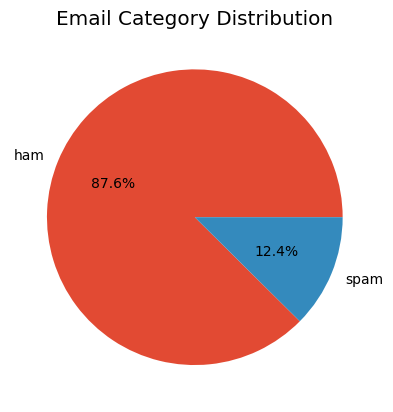

In [72]:
df["Category"].value_counts().plot(
    kind= "pie",
    autopct = "%1.1f%%"
)

plt.ylabel("")
plt.title("Email Category Distribution")
plt.show()

In [73]:
df["Message_Length"] = df["Message"].apply(len)
df.head()

C:\Users\USER\AppData\Local\Temp\ipykernel_8276\3451340940.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["Message_Length"] = df["Message"].apply(len)


,Category,Message,Message_Length
0,ham,"Go until jurong point, crazy.. Available only ...",111
1,ham,Ok lar... Joking wif u oni...,29
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,155
3,ham,U dun say so early hor... U c already then say...,49
4,ham,"Nah I don't think he goes to usf, he lives aro...",61


In [75]:
df["Message_Length"].describe()

count    5157.000000
mean       79.103936
std        58.382922
min         2.000000
25%        36.000000
50%        61.000000
75%       118.000000
max       910.000000
Name: Message_Length, dtype: float64

In [76]:
df["Message"][1]

'Ok lar... Joking wif u oni...'

In [80]:
df["Message_Length"].median()

61.0

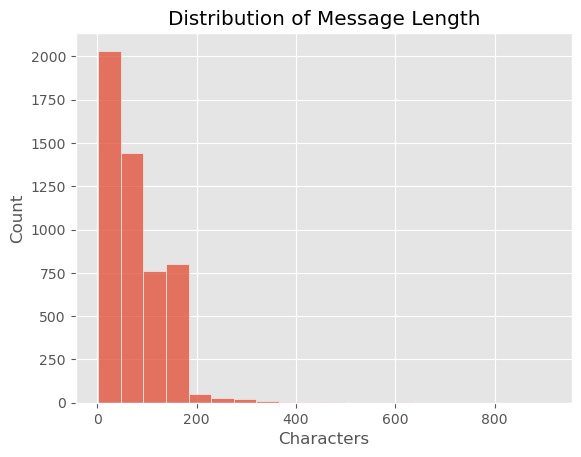

In [79]:
sns.histplot(df["Message_Length"], bins=20)

plt.title("Distribution of Message Length")

plt.xlabel("Characters")

plt.show()

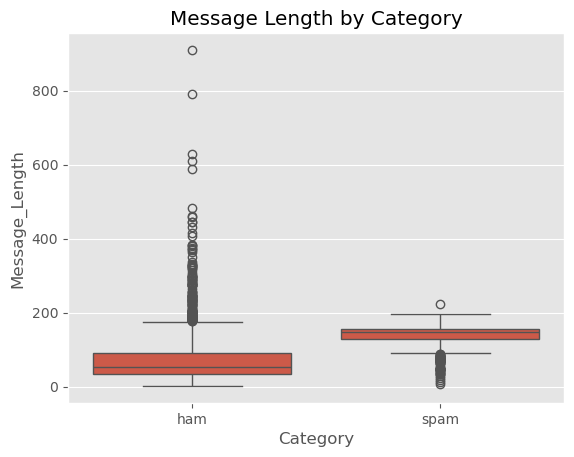

In [82]:
sns.boxplot(
    data = df,
    x = "Category",
    y = "Message_Length",
)

plt.title("Message Length by Category")

plt.show()

In [83]:
df.groupby("Category")["Message_Length"].mean()

Category
ham      70.869353
spam    137.118565
Name: Message_Length, dtype: float64

Text(0.5, 1.0, 'Average Message Length')

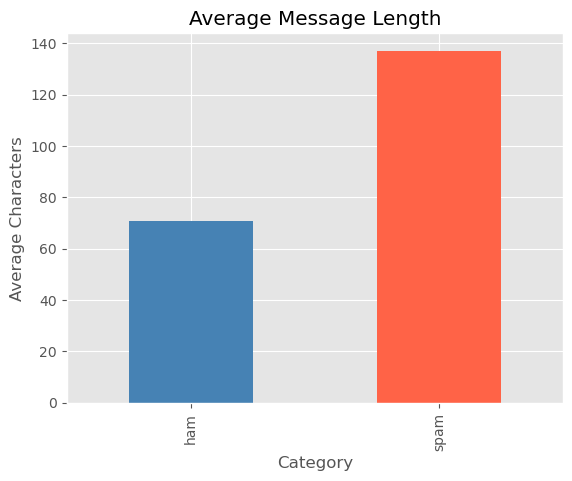

In [84]:
df.groupby("Category")["Message_Length"].mean().plot(
    kind = "bar",
    color = ["steelblue", "tomato"]
)

plt.ylabel("Average Characters")
plt.title("Average Message Length")

In [85]:
df.head()

,Category,Message,Message_Length
0,ham,"Go until jurong point, crazy.. Available only ...",111
1,ham,Ok lar... Joking wif u oni...,29
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,155
3,ham,U dun say so early hor... U c already then say...,49
4,ham,"Nah I don't think he goes to usf, he lives aro...",61


In [86]:
df["Word_Count"] = df["Message"].apply(lambda x: len(x.split()))
df.head()

C:\Users\USER\AppData\Local\Temp\ipykernel_8276\4087440344.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["Word_Count"] = df["Message"].apply(lambda x: len(x.split()))


,Category,Message,Message_Length,Word_Count
0,ham,"Go until jurong point, crazy.. Available only ...",111,20
1,ham,Ok lar... Joking wif u oni...,29,6
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,155,28
3,ham,U dun say so early hor... U c already then say...,49,11
4,ham,"Nah I don't think he goes to usf, he lives aro...",61,13


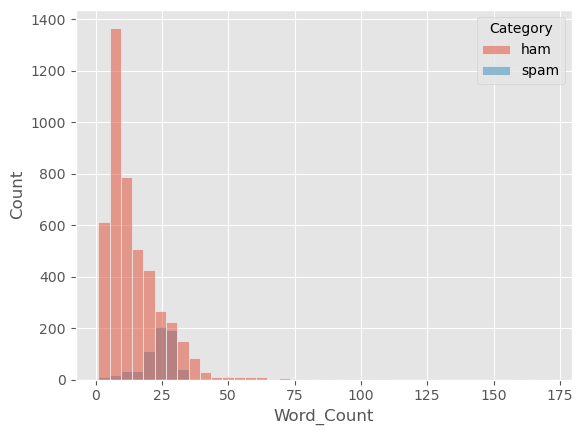

In [90]:
sns.histplot(
    data = df,
    x = "Word_Count",
    hue = "Category",
    bins = 40)

plt.show()

In [91]:
df.groupby("Category")["Word_Count"].mean()

Category
ham     14.239814
spam    23.659906
Name: Word_Count, dtype: float64

In [92]:
df.nsmallest(10, "Message_Length")

,Category,Message,Message_Length,Word_Count
1925,ham,Ok,2,1
3376,ham,:),2,1
261,ham,Yup,3,1
1612,ham,645,3,1
2182,ham,Ok.,3,1
287,ham,Ok..,4,1
2602,ham,Okie,4,1
5173,ham,U 2.,4,2
1273,ham,Ok...,5,1
4293,ham,G.W.R,5,1


In [93]:
df.nlargest(10, "Message_Length")

,Category,Message,Message_Length,Word_Count
1085,ham,For me the love should start with attraction.i...,910,171
1863,ham,The last thing i ever wanted to do was hurt yo...,790,162
2434,ham,Indians r poor but India is not a poor country...,629,109
1579,ham,How to Make a girl Happy? It's not at all diff...,611,103
2158,ham,Sad story of a Man - Last week was my b'day. M...,588,125
2380,ham,"Good evening Sir, hope you are having a nice d...",482,98
3017,ham,"&lt;#&gt; is fast approaching. So, Wish u a v...",461,66
1513,ham,"Hey sweet, I was wondering when you had a mome...",458,95
2370,ham,A Boy loved a gal. He propsd bt she didnt mind...,446,96
2408,ham,Solve d Case : A Man Was Found Murdered On &l...,444,71


In [96]:
df[df["Category"] == "spam"].sample(5)

,Category,Message,Message_Length,Word_Count
3064,spam,"Hi babe its Jordan, how r u? Im home from abro...",147,28
1745,spam,Someone has conacted our dating service and en...,155,24
19,spam,England v Macedonia - dont miss the goals/team...,155,24
2620,spam,<Forwarded from 21870000>Hi - this is your Mai...,173,27
4808,spam,PRIVATE! Your 2004 Account Statement for 07849...,153,21


In [101]:
df[df["Category"] == "ham"].sample(5, random_state=1)

,Category,Message,Message_Length,Word_Count
1258,ham,Am also doing in cbe only. But have to pay.,43,10
5180,ham,Babe! I fucking love you too !! You know? Fuck...,157,34
1296,ham,TELL HER I SAID EAT SHIT.,25,6
4886,ham,Poor girl can't go one day lmao,31,7
266,ham,Same. Wana plan a trip sometme then,35,7


In [102]:
df["Category"] = df["Category"].map({
    "ham" : 0,
    "spam" : 1
})

df.head()

C:\Users\USER\AppData\Local\Temp\ipykernel_8276\3687493423.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["Category"] = df["Category"].map({


,Category,Message,Message_Length,Word_Count
0,0,"Go until jurong point, crazy.. Available only ...",111,20
1,0,Ok lar... Joking wif u oni...,29,6
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,28
3,0,U dun say so early hor... U c already then say...,49,11
4,0,"Nah I don't think he goes to usf, he lives aro...",61,13


In [104]:
import warnings
warnings.filterwarnings("ignore")

In [106]:
from sklearn.model_selection import train_test_split



In [107]:
X = df["Message"]

In [108]:
y = df["Category"]

In [110]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify= y
)

In [111]:
# Converted messages into numerical vectors using tfidf
from sklearn.feature_extraction.text import TfidfVectorizer


In [112]:
tfidf = TfidfVectorizer(stop_words= "english",
                        max_features= 5000,
                        ngram_range = (1,2)
                       )
            

In [113]:
X_train_tfidf = tfidf.fit_transform(X_train)

In [114]:
X_test_tfidf = tfidf.transform(X_test)

In [131]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier

from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.model_selection import RandomizedSearchCV
# We can look for diff parameters in the hyper parameter space
# We are just trying to the diff parameters and we are going to try
# to find the best performing ones.

In [132]:


models = {
    "NaiveBayes":(
        MultinomialNB(),
        {
            "alpha" : [0.1, 0.5, 1, 2, 5]
        }
    ),

    "LogisticRegression" : (
        LogisticRegression(
            class_weight = "balanced",
            max_iter = 1000
        ),
        {
            "C" : [0.01, 0.1, 1, 10, 100]
        }
    ),

    "Linear SVM" : (
        LinearSVC(
            class_weight = "balanced"
        ),
        {
            "C" : [0.01, 0.1, 1, 10]
        }
    ),

    "Random Forest" : (
        RandomForestClassifier(
            class_weight = "balanced"
        ),
        {
            "n_estimators" : [100, 200, 300],
            "max_depth" : [10, 20, None],
            "min_samples_split" : [2, 5, 10]
        }
            
    ),

    "Decision Tree" : (
        DecisionTreeClassifier(
            class_weight = "balanced"
        ),
        {
            "max_depth" : [5, 10, 20, None],
            "min_samples_split" : [2, 5, 10]
        }
    ),

    "Gradient Boosting" : (
        GradientBoostingClassifier(),
        {
            "n_estimators" : [100, 200],
            "learning_rate" : [0.01, 0.05, 0.1],
            "max_depth" : [3,5]
        }
    ),

    "KNN" : (
        KNeighborsClassifier(),
        {
            "n_neighbors": [3, 5, 7, 9]
        }
    )

}
        
            
    
    
        

In [133]:
# Train and compared Multiple Machine Learning models with hyperparameter tuning
# selected the best performing model 
# and finally exported both trained classifier and TF-IDF

results = []

best_models = {}

for name, (model, params) in models.items():

    search = RandomizedSearchCV(
        estimator = model,
        param_distributions = params,
        n_iter = 10,
        cv = 5,
        scoring = "f1",
        n_jobs = -1
    )

    search.fit(X_train_tfidf, y_train)

    best_model = search.best_estimator_

    best_models[name] = best_model

    predictions = best_model.predict(X_test_tfidf)

    accuracy = accuracy_score(y_test, predictions)
    precision = precision_score(y_test, predictions)
    recall = recall_score(y_test, predictions)
    f1 = f1_score(y_test, predictions)

    try:
        auc = roc_auc_score(y_test, best_model.decision_function(X_test_tfidf))
    except:
        try:
            auc = roc_auc_score(
                y_test,
                best_model.predic_proba(X_test_tfidf)[:, 1]
            )
        except:
            auc = np.nan

    results.append({
        "Model" : name,
        "Accuracy" : accuracy,
        "Precision" : precision,
        "Recall" : recall,
        "F1 Score" : f1,
        "ROC AUC" : auc,
        "Best Params" : search.best_params_
    })
        




    

In [134]:
results

[{'Model': 'NaiveBayes',
  'Accuracy': 0.9864341085271318,
  'Precision': 0.9913793103448276,
  'Recall': 0.8984375,
  'F1 Score': 0.9426229508196722,
  'ROC AUC': nan,
  'Best Params': {'alpha': 0.1}},
 {'Model': 'LogisticRegression',
  'Accuracy': 0.9864341085271318,
  'Precision': 0.9596774193548387,
  'Recall': 0.9296875,
  'F1 Score': 0.9444444444444444,
  'ROC AUC': 0.9928659084623894,
  'Best Params': {'C': 10}},
 {'Model': 'Linear SVM',
  'Accuracy': 0.9844961240310077,
  'Precision': 0.9516129032258065,
  'Recall': 0.921875,
  'F1 Score': 0.9365079365079365,
  'ROC AUC': 0.9911850110619469,
  'Best Params': {'C': 1}},
 {'Model': 'Random Forest',
  'Accuracy': 0.9854651162790697,
  'Precision': 1.0,
  'Recall': 0.8828125,
  'F1 Score': 0.9377593360995851,
  'ROC AUC': nan,
  'Best Params': {'n_estimators': 100,
   'min_samples_split': 5,
   'max_depth': None}},
 {'Model': 'Decision Tree',
  'Accuracy': 0.9622093023255814,
  'Precision': 0.8617886178861789,
  'Recall': 0.828125,

In [140]:
results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by = ["F1 Score", "ROC AUC"],
    ascending = False)

In [141]:
results_df

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC,Best Params
1,LogisticRegression,0.986434,0.959677,0.929688,0.944444,0.992866,{'C': 10}
0,NaiveBayes,0.986434,0.991379,0.898438,0.942623,NaN,{'alpha': 0.1}
3,Random Forest,0.985465,1.000000,0.882812,0.937759,NaN,"{'n_estimators': 100, 'min_samples_split': 5, ..."
2,Linear SVM,0.984496,0.951613,0.921875,0.936508,0.991185,{'C': 1}
5,Gradient Boosting,0.976744,0.972727,0.835938,0.899160,0.981588,"{'n_estimators': 200, 'max_depth': 5, 'learnin..."
4,Decision Tree,0.962209,0.861789,0.828125,0.844622,NaN,"{'min_samples_split': 5, 'max_depth': 20}"
6,KNN,0.923450,1.000000,0.382812,0.553672,NaN,{'n_neighbors': 3}


In [151]:
results_df.style.background_gradient(
    cmap = "Greens",
    subset = ["Accuracy", "Precision", "Recall","F1 Score",	"ROC AUC"]
)

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC,Best Params
0,LogisticRegression,0.986434,0.959677,0.929688,0.944444,0.992866,{'C': 10}
1,NaiveBayes,0.986434,0.991379,0.898438,0.942623,nan,{'alpha': 0.1}
2,Random Forest,0.985465,1.000000,0.882812,0.937759,nan,"{'n_estimators': 100, 'min_samples_split': 5, 'max_depth': None}"
3,Linear SVM,0.984496,0.951613,0.921875,0.936508,0.991185,{'C': 1}
4,Gradient Boosting,0.976744,0.972727,0.835938,0.899160,0.981588,"{'n_estimators': 200, 'max_depth': 5, 'learning_rate': 0.1}"
5,Decision Tree,0.962209,0.861789,0.828125,0.844622,nan,"{'min_samples_split': 5, 'max_depth': 20}"
6,KNN,0.923450,1.000000,0.382812,0.553672,nan,{'n_neighbors': 3}


In [152]:
results_df.reset_index(inplace=True)

In [154]:
results_df.drop(columns="index", inplace=True)

In [155]:
results_df

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC,Best Params
0,LogisticRegression,0.986434,0.959677,0.929688,0.944444,0.992866,{'C': 10}
1,NaiveBayes,0.986434,0.991379,0.898438,0.942623,NaN,{'alpha': 0.1}
2,Random Forest,0.985465,1.000000,0.882812,0.937759,NaN,"{'n_estimators': 100, 'min_samples_split': 5, ..."
3,Linear SVM,0.984496,0.951613,0.921875,0.936508,0.991185,{'C': 1}
4,Gradient Boosting,0.976744,0.972727,0.835938,0.899160,0.981588,"{'n_estimators': 200, 'max_depth': 5, 'learnin..."
5,Decision Tree,0.962209,0.861789,0.828125,0.844622,NaN,"{'min_samples_split': 5, 'max_depth': 20}"
6,KNN,0.923450,1.000000,0.382812,0.553672,NaN,{'n_neighbors': 3}


In [156]:
best_model_name = results_df.iloc[0]["Model"]
best_model_name

'LogisticRegression'

In [157]:
best_model = best_models[best_model_name]

In [158]:
best_model

,penalty,'l2'
,dual,False
,tol,0.0001
,C,10
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


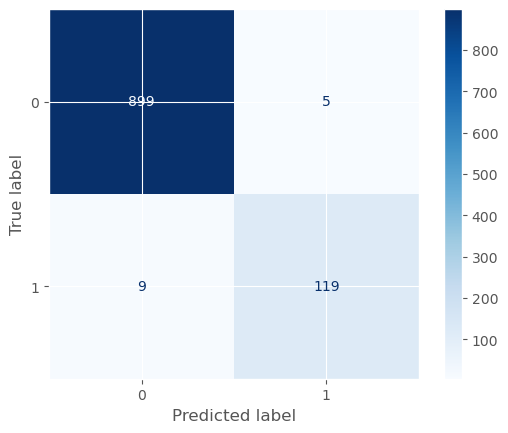

In [161]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator(
    best_model,
    X_test_tfidf,
    y_test,
    cmap= "Blues"
)

plt.show()


    

In [169]:
emails = [

    " Congratulations! You won a free iPhone. Click here now.",

    "Hey don't forget our meeting tomorrow at 3 PM.",

    "URGENT! Your bank account has been suspended. Verify Immediately.",

    "Can you pick up some groceries on your way home?",

    "You have been selected to receive a $500 Amazon gift card",

    "Happy Birthday! Wishing you wonderful day ahead.",

    "Limited-time offer! Buy one, get one free. Shop today!",

    "I'll send you the project files once I reach home.",

    "Claim your lottery prize by clicking the link below.",

    "Let's have lunch together this weekend."

    "Hey, we are still meeting tomorrow at 10 AM?",

    "URGENT! Claim your $1000 Walmart Gift Card Today."
]

emails_vectorized = tfidf.transform(emails)

predictions = best_model.predict(emails_vectorized)

for email, predictions in zip(emails, predictions):
    label = "Spam" if predictions == 1 else "Ham"
    
    print(f"Email : {email}")
    print(f"Prediction : {label}")
    print("-" * 70)
    

Email :  Congratulations! You won a free iPhone. Click here now.
Prediction : Spam
----------------------------------------------------------------------
Email : Hey don't forget our meeting tomorrow at 3 PM.
Prediction : Ham
----------------------------------------------------------------------
Email : URGENT! Your bank account has been suspended. Verify Immediately.
Prediction : Spam
----------------------------------------------------------------------
Email : Can you pick up some groceries on your way home?
Prediction : Ham
----------------------------------------------------------------------
Email : You have been selected to receive a $500 Amazon gift card
Prediction : Spam
----------------------------------------------------------------------
Email : Happy Birthday! Wishing you wonderful day ahead.
Prediction : Ham
----------------------------------------------------------------------
Email : Limited-time offer! Buy one, get one free. Shop today!
Prediction : Ham
---------------

In [171]:
import pickle

with open("spam_classifier.pkl", "wb") as file:

    pickle.dump(best_model, file)




In [172]:
with open("tfidf_vectorizer.pkl", "wb") as file:
    pickle.dump(tfidf, file)

print("Success")

Success


In [174]:
with open("spam_classifier.pkl", "rb") as file:
    loaded_model = pickle.load(file)

with open("tfidf_vectorizer.pkl", "rb") as file:

    loaded_vectorizer = pickle.load(file)

In [175]:
email = [
    "Cingratulations! You have won $1000. Click here to Claim."
]

email_vector = loaded_vectorizer.transform(email)

prediction =  loaded_model.predict(email_vector)[0]



In [176]:
print("Spam" if prediction == 1 else "Ham")

Spam
